In [2]:
import numpy as np
import matplotlib.pyplot as plt

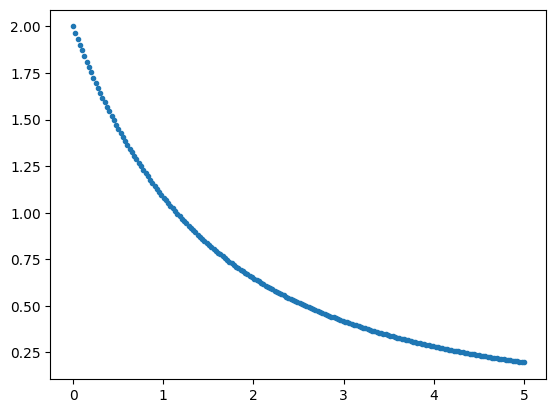

In [51]:
tau1 = 1
tau2 = 3
x = np.linspace(0,5,200)
y = np.exp(-x/tau1)+ np.exp(-x/tau2) + 0.0*np.random.randn(200)
#y /= np.sum(y)
plt.plot(x,y,".")
plt.show()
def log_likelihood(X):
    tau1_ = X[0]
    tau2_ = X[1]
    if (tau1_<0) | (tau2_<0):
        return -np.inf
    y_ = np.exp(-x/tau1) + np.exp(-x/tau2)
#    y_ /= np.sum(y_)
    f = y - y_
    return np.sum(-f**2)

acceptance rate: 0.999


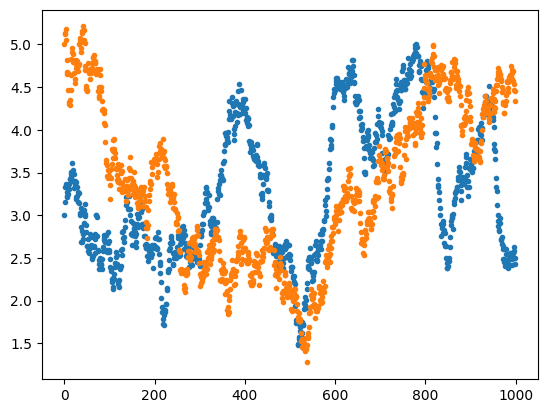

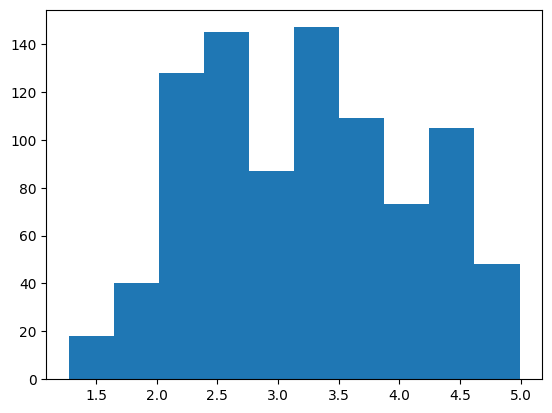

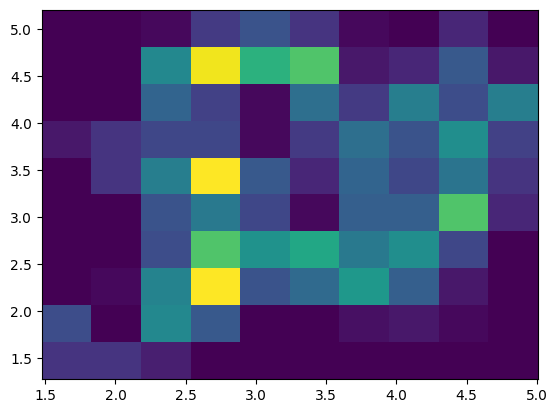

In [53]:
init_param_guess = [3,5]
num_reps = 1000
jump_mag = [0.1,0.1]
param_its = np.zeros((2,num_reps))
param_its[:,0] = init_param_guess
rands = np.random.uniform(0,1,(num_reps))
acceptances = 0
loglikes = np.zeros_like(rands)
for i in range(num_reps-1):
    my_likelihood = log_likelihood(param_its[:,i])
    jump = jump_mag * np.random.randn(np.size(init_param_guess))
    loglikes[i] = my_likelihood
    new_params = param_its[:,i] + jump
    new_likelihood = log_likelihood(new_params)
    if new_likelihood > my_likelihood:
        param_its[:,i+1] = new_params
        acceptances += 1
    elif rands[i] <np.exp(new_likelihood - my_likelihood):
        param_its[:,i+1] = new_params
        acceptances += 1
    else:
        param_its[:,i+1] = param_its[:,i]
print("acceptance rate: {}".format(acceptances/num_reps))
plt.plot(np.arange(num_reps),param_its.T,".")
plt.show()
plt.hist(param_its[1,100:])
plt.show()
plt.hist2d(param_its[0,:],param_its[1,:])
plt.show()